<a href="https://colab.research.google.com/github/payal-web/silver-price-prediction/blob/main/silver_price_pred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

# Time Series
from prophet import Prophet
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print('All libraries imported successfully!')

All libraries imported successfully!


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving silver_prices_data (1).csv to silver_prices_data (1).csv


In [ ]:
import pandas as pd

df = pd.read_csv("silver_prices_data (1).csv")

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Drop Volume if it's all NaN
if 'Volume' in df.columns:
    df.drop(columns=['Volume'], inplace=True)

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'silver_prices_data (1).csv'

In [ ]:
# Dataset Info
print('Dataset Information:')
print(df.info())
print('\nStatistical Summary:')
df.describe().round(2)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2513 entries, 2016-01-19 to 2026-01-15
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Price   2513 non-null   float64
 1   Close   2513 non-null   float64
 2   High    2513 non-null   float64
 3   Low     2513 non-null   float64
 4   Open    2513 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 117.8 KB
None

Statistical Summary:


,Price,Close,High,Low,Open
count,2513.00,2513.00,2513.00,2513.00,2513.00
mean,22.81,22.98,22.65,22.81,1777.77
std,8.85,9.00,8.67,8.82,10141.05
min,11.73,12.20,11.73,12.07,0.00
25%,16.83,16.91,16.76,16.84,10.00
50%,21.40,21.59,21.07,21.33,49.00
75%,25.51,25.72,25.27,25.51,177.00
max,91.88,93.00,88.71,90.82,131415.00


In [ ]:
# Check for missing values
missing = df.isnull().sum()
print('Missing Values Analysis:')
print(missing)
print(f'\nMissing value percentage: {(missing.sum() / len(df) * 100):.2f}%')

Missing Values Analysis:
Price    0
Close    0
High     0
Low      0
Open     0
dtype: int64

Missing value percentage: 0.00%


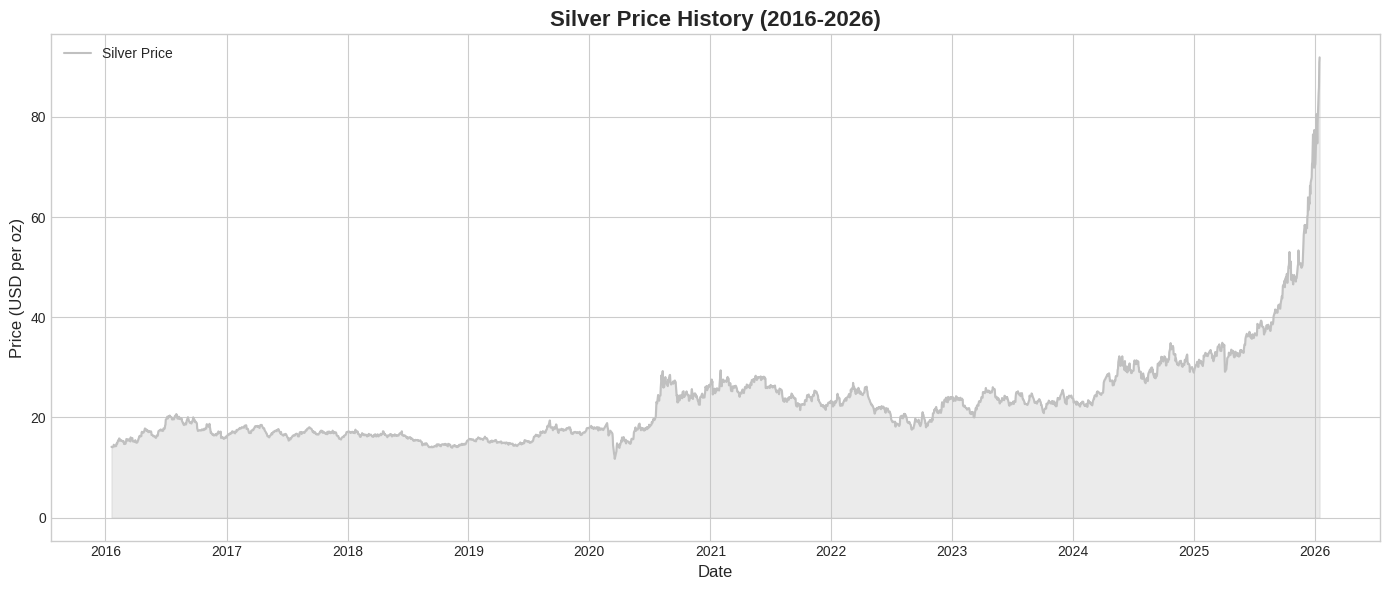

In [ ]:
# Silver Price Over Time
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df['Price'], color='#C0C0C0', linewidth=1.5, label='Silver Price')
ax.fill_between(df.index, df['Price'], alpha=0.3, color='silver')
ax.set_title('Silver Price History (2016-2026)', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price (USD per oz)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

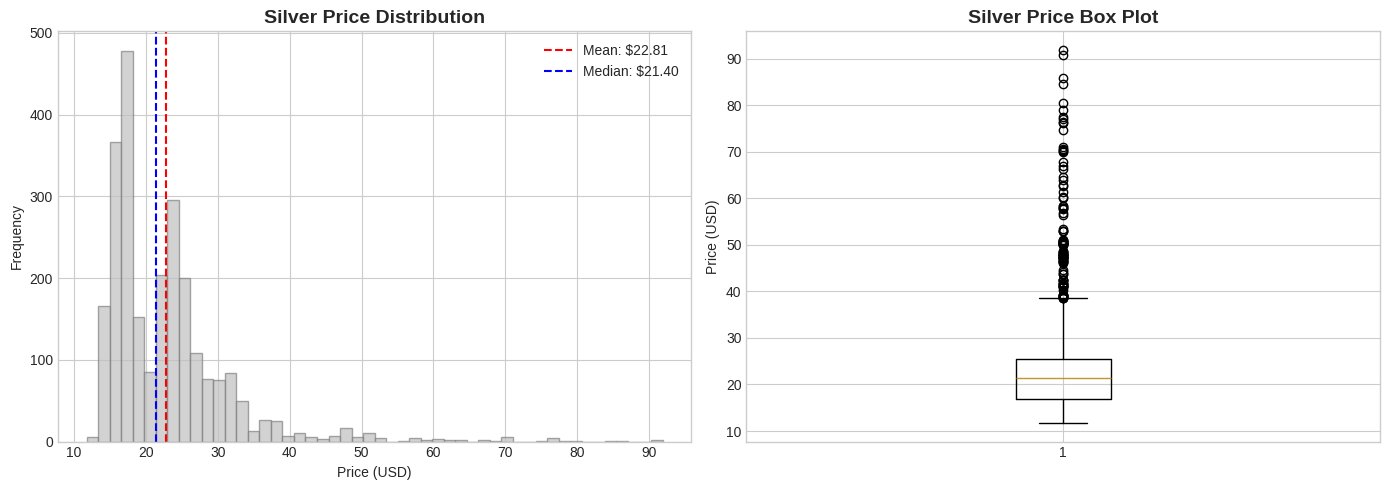

In [ ]:
# Price Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['Price'], bins=50, color='silver', edgecolor='gray', alpha=0.7)
axes[0].axvline(df['Price'].mean(), color='red', linestyle='--', label=f'Mean: ${df["Price"].mean():.2f}')
axes[0].axvline(df['Price'].median(), color='blue', linestyle='--', label=f'Median: ${df["Price"].median():.2f}')
axes[0].set_title('Silver Price Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box Plot
axes[1].boxplot(df['Price'].dropna(), vert=True)
axes[1].set_title('Silver Price Box Plot', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Price (USD)')

plt.tight_layout()
plt.show()


In [ ]:
# Yearly Analysis
df['Year'] = df.index.year
yearly_stats = df.groupby('Year')['Price'].agg(['mean', 'min', 'max', 'std']).round(2)
yearly_stats.columns = ['Avg Price', 'Min Price', 'Max Price', 'Volatility']
print('Yearly Silver Price Statistics:')
yearly_stats

Yearly Silver Price Statistics:


,Avg Price,Min Price,Max Price,Volatility
Year,,,,
2016,17.27,14.04,20.67,1.73
2017,17.02,15.37,18.49,0.67
2018,15.65,13.95,17.55,1.04
2019,16.16,14.28,19.39,1.19
2020,20.65,11.73,29.25,4.42
2021,25.14,21.46,29.40,1.78
2022,21.76,17.55,26.89,2.30
2023,23.39,20.00,26.03,1.20
2024,28.30,22.10,34.83,3.26


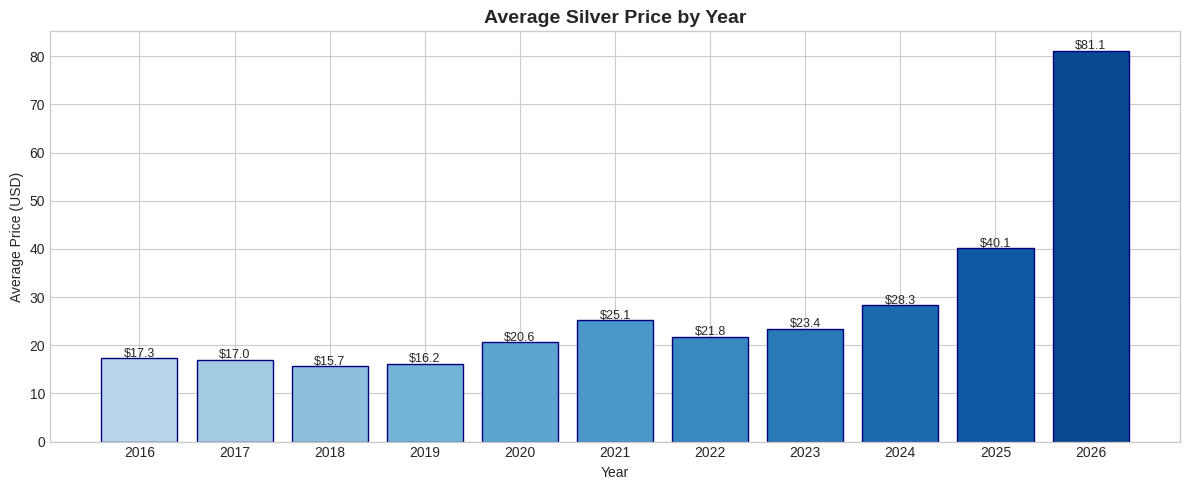

In [ ]:
 #Yearly Average Price Bar Chart
fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(yearly_stats)))
bars = ax.bar(yearly_stats.index.astype(str), yearly_stats['Avg Price'], color=colors, edgecolor='navy')
ax.set_title('Average Silver Price by Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Average Price (USD)')
for bar, val in zip(bars, yearly_stats['Avg Price']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'${val:.1f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


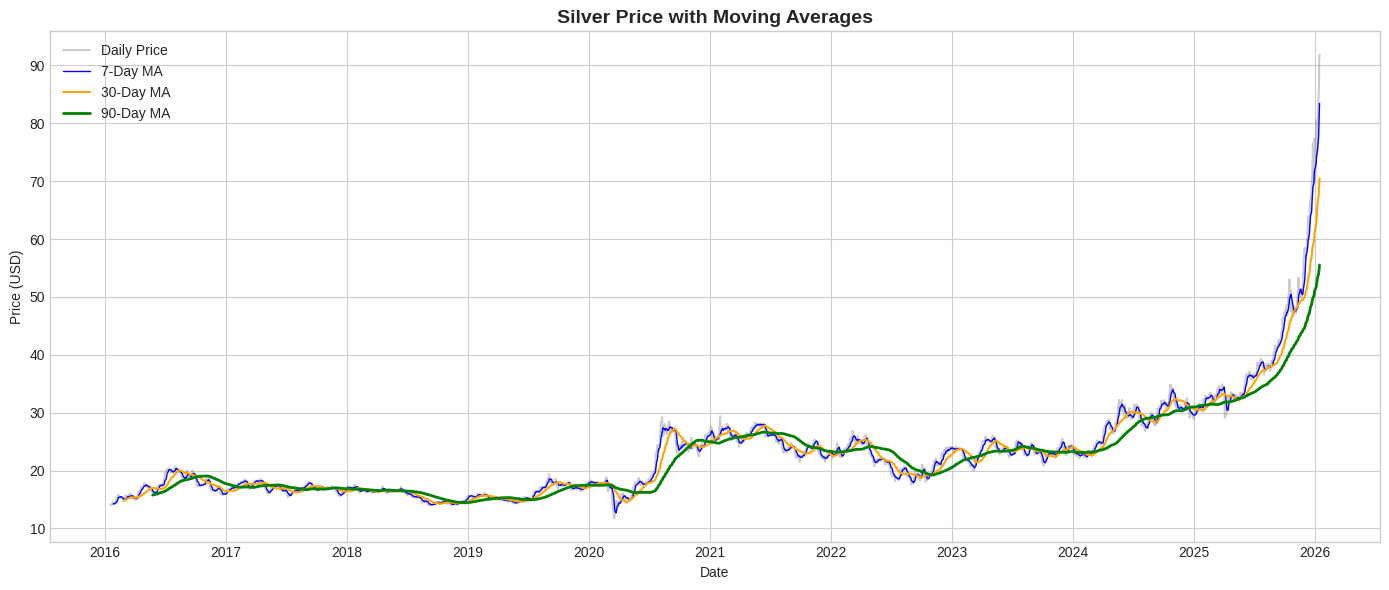

In [ ]:
# Moving Averages
df['MA_7'] = df['Price'].rolling(window=7).mean()
df['MA_30'] = df['Price'].rolling(window=30).mean()
df['MA_90'] = df['Price'].rolling(window=90).mean()
df['MA_365'] = df['Price'].rolling(window=365).mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df['Price'], alpha=0.4, label='Daily Price', color='gray')
ax.plot(df.index, df['MA_7'], label='7-Day MA', color='blue', linewidth=1)
ax.plot(df.index, df['MA_30'], label='30-Day MA', color='orange', linewidth=1.5)
ax.plot(df.index, df['MA_90'], label='90-Day MA', color='green', linewidth=2)
ax.set_title('Silver Price with Moving Averages', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.show()

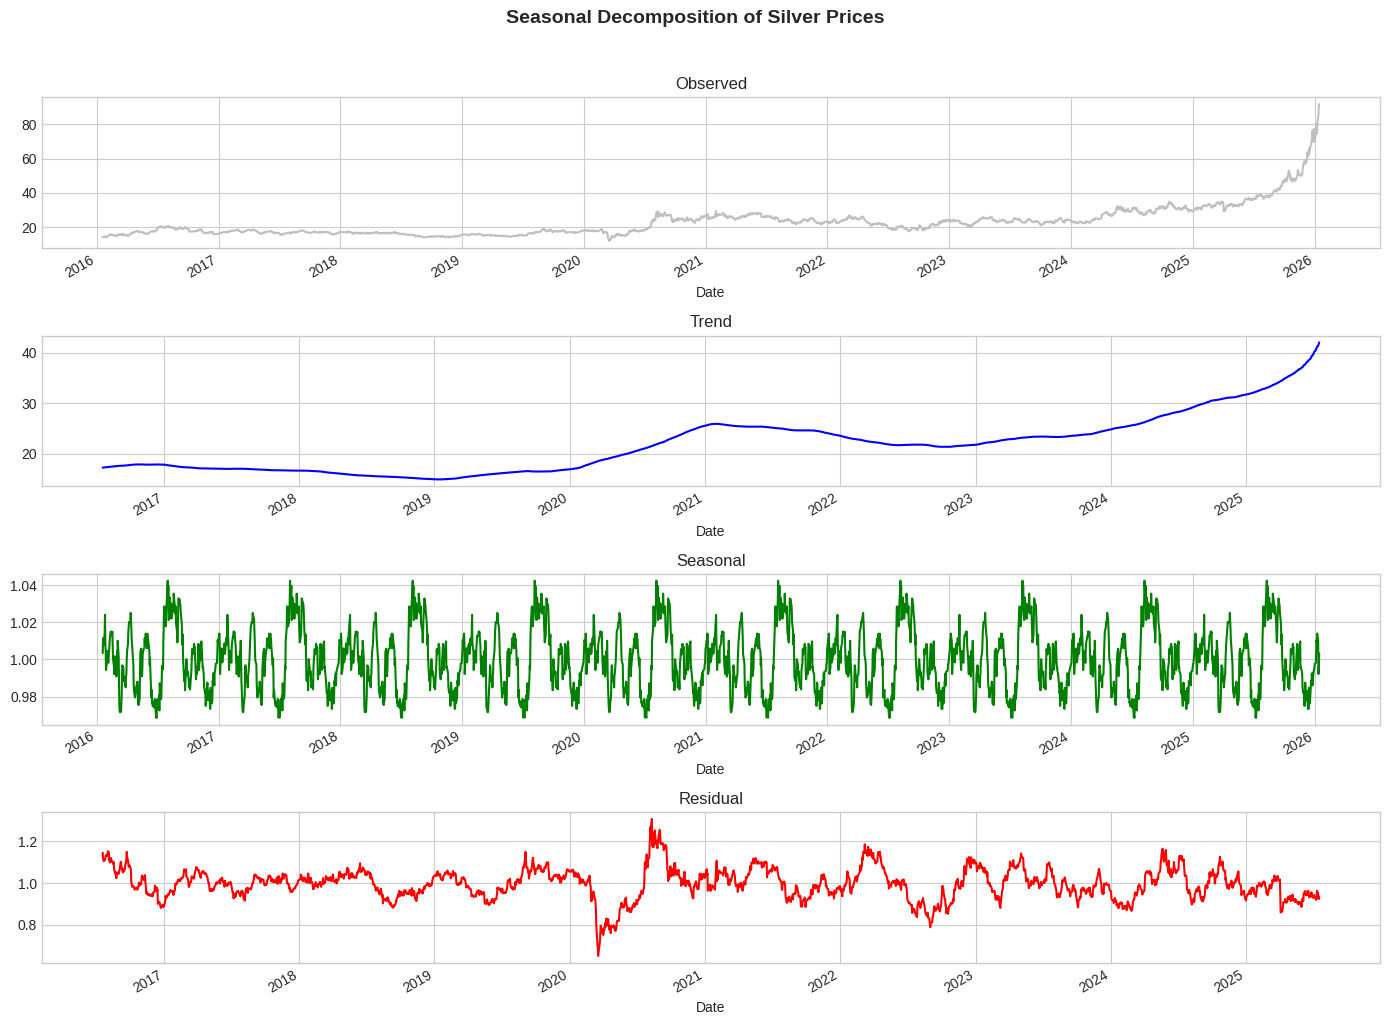

In [ ]:
# Seasonal Decomposition
decomposition = seasonal_decompose(df['Price'].dropna(), model='multiplicative', period=252)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomposition.observed.plot(ax=axes[0], title='Observed', color='silver')
decomposition.trend.plot(ax=axes[1], title='Trend', color='blue')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal', color='green')
decomposition.resid.plot(ax=axes[3], title='Residual', color='red')
plt.suptitle('Seasonal Decomposition of Silver Prices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Stationarity Test (ADF)
result = adfuller(df['Price'].dropna())
print('Augmented Dickey-Fuller Test:')
print(f'   ADF Statistic: {result[0]:.4f}')
print(f'   p-value: {result[1]:.4f}')
print(f'   Critical Values:')
for key, value in result[4].items():
    print(f'      {key}: {value:.4f}')
print(f'\n   Series is {"stationary" if result[1] < 0.05 else "non-stationary"}')

Augmented Dickey-Fuller Test:
   ADF Statistic: 5.2203
   p-value: 1.0000
   Critical Values:
      1%: -3.4330
      5%: -2.8627
      10%: -2.5674

   Series is non-stationary


In [ ]:
# Create Features
df['Daily_Return'] = df['Price'].pct_change() * 100
df['Volatility_7d'] = df['Daily_Return'].rolling(7).std()
df['Volatility_30d'] = df['Daily_Return'].rolling(30).std()
df['Price_Range'] = df['High'] - df['Low']
df['Month'] = df.index.month
df['DayOfWeek'] = df.index.dayofweek
df['Quarter'] = df.index.quarter

# Lag Features
for lag in [1, 7, 14, 30]:
    df[f'Price_Lag_{lag}'] = df['Price'].shift(lag)

print('Feature Engineering Complete!')
print(f'Total Features: {len(df.columns)}')
df.head()

Feature Engineering Complete!
Total Features: 21


,Price,Close,High,Low,Open,Year,MA_7,MA_30,MA_90,MA_365,...,Volatility_7d,Volatility_30d,Price_Range,Month,DayOfWeek,Quarter,Price_Lag_1,Price_Lag_7,Price_Lag_14,Price_Lag_30
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-19,14.110,14.110,14.065,14.065,3,2016,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000,1,1,1,NaN,NaN,NaN,NaN
2016-01-20,14.147,14.147,14.147,14.147,1,2016,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000,1,2,1,14.110,NaN,NaN,NaN
2016-01-21,14.083,14.083,14.083,14.083,2,2016,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000,1,3,1,14.147,NaN,NaN,NaN
2016-01-22,14.043,14.290,14.043,14.290,7,2016,NaN,NaN,NaN,NaN,...,NaN,NaN,-0.247,1,4,1,14.083,NaN,NaN,NaN
2016-01-25,14.240,14.240,14.095,14.095,8,2016,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000,1,0,1,14.043,NaN,NaN,NaN


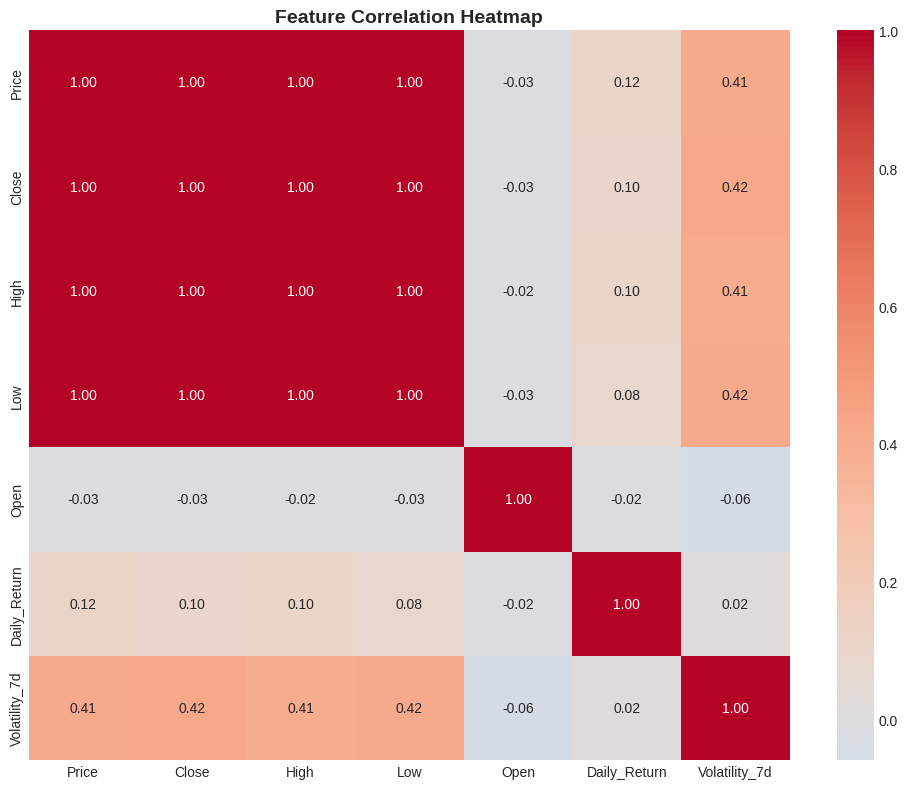

In [ ]:
# Correlation Heatmap
corr_cols = ['Price', 'Close', 'High', 'Low', 'Open', 'Daily_Return', 'Volatility_7d']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# Moving averages
df['MA10'] = df['Close'].rolling(window=10).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()

# RSI (manual version - no library needed)
delta = df['Close'].diff()

gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()

rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# Drop missing values
df.dropna(inplace=True)

In [ ]:
df['Target'] = df['Close'].shift(-1)
df.dropna(inplace=True)

In [ ]:
X = df[['Close', 'MA10', 'MA50', 'RSI']]
y = df['Target']

In [ ]:
#linearregression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Features and target
X = df[['Close', 'MA10', 'MA50', 'RSI']]
y = df['Target']

# Train-test split (VERY IMPORTANT for time series)
split = int(len(df) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
lr_pred = lr_model.predict(X_test)

# Evaluation
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

print("Linear Regression MAE:", lr_mae)
print("Linear Regression RMSE:", lr_rmse)

Linear Regression MAE: 0.6197267679485393
Linear Regression RMSE: 1.0096908806544524


In [ ]:
# Prepare data for Prophet
prophet_df = df[['Price']].reset_index()
prophet_df.columns = ['ds', 'y']
prophet_df = prophet_df.dropna()

# Train-test split
train_size = int(len(prophet_df) * 0.8)
train = prophet_df[:train_size]
test = prophet_df[train_size:]

print(f'Training samples: {len(train)}')
print(f'Testing samples: {len(test)}')

Training samples: 1679
Testing samples: 420


In [ ]:
# Train Prophet Model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10
)
model.fit(train)
print('Prophet model trained successfully!')

Prophet model trained successfully!


In [ ]:
# Make predictions on test set
test_forecast = model.predict(test[['ds']])

# Calculate metrics
y_true = test['y'].values
y_pred = test_forecast['yhat'].values

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)

print('Prophet Model Evaluation Metrics:')
print(f'   RMSE: ${rmse:.2f}')
print(f'   MAE:  ${mae:.2f}')
print(f'   MAPE: {mape:.2f}%')
print(f'   R2:   {r2:.4f}')

Prophet Model Evaluation Metrics:
   RMSE: $14.82
   MAE:  $10.55
   MAPE: 24.33%
   R2:   -0.7865


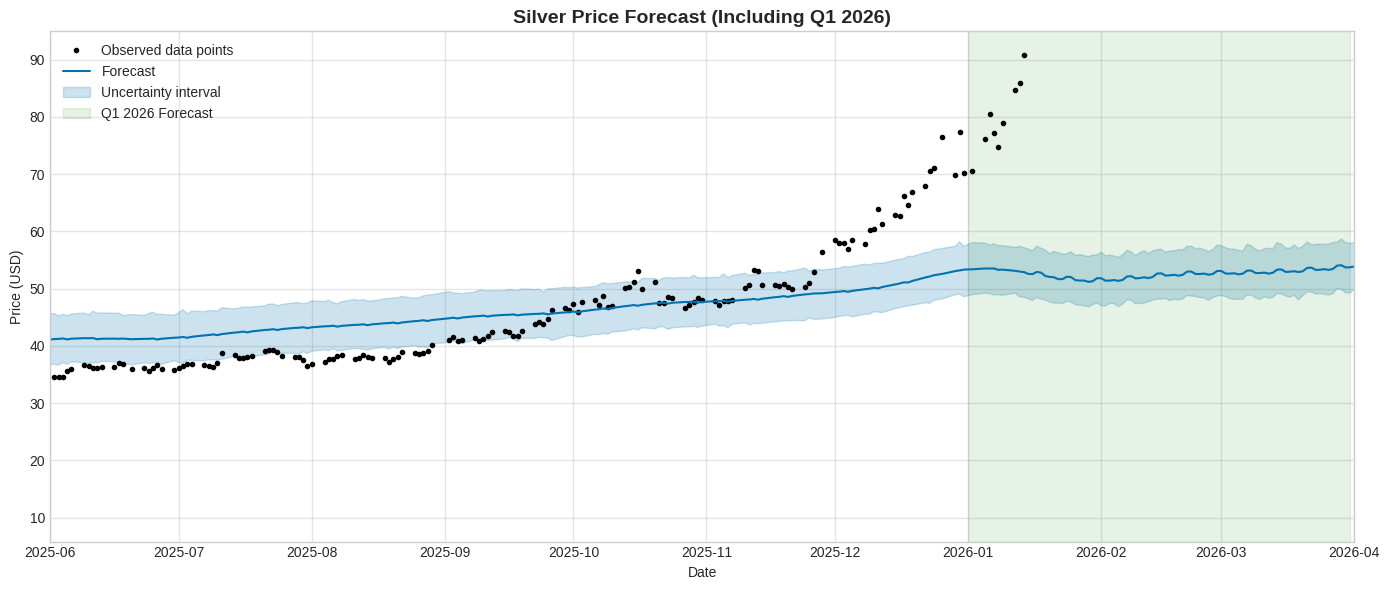

In [ ]:
# Retrain on full dataset for future forecast
model_full = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10
)
model_full.fit(prophet_df)

# Forecast for Q1 2026 (Jan, Feb, Mar)
future_dates = model_full.make_future_dataframe(periods=90, freq='D')
forecast = model_full.predict(future_dates)

# Ensure ds is datetime
forecast['ds'] = pd.to_datetime(forecast['ds'])

# Filter for specific Q1 2026 range
start_date = pd.to_datetime('2026-01-01')
end_date = pd.to_datetime('2026-03-31')
forecast_q1_2026 = forecast[(forecast['ds'] >= start_date) & (forecast['ds'] <= end_date)]

# Plot forecast
fig = model_full.plot(forecast, figsize=(14, 6))
plt.title('Silver Price Forecast (Including Q1 2026)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
# Highlight Q1 2026
plt.axvspan(start_date, end_date, color='green', alpha=0.1, label='Q1 2026 Forecast')
plt.legend()
plt.xlim(pd.to_datetime('2025-06-01'), pd.to_datetime('2026-04-01')) # Zoom in
plt.tight_layout()
plt.show()

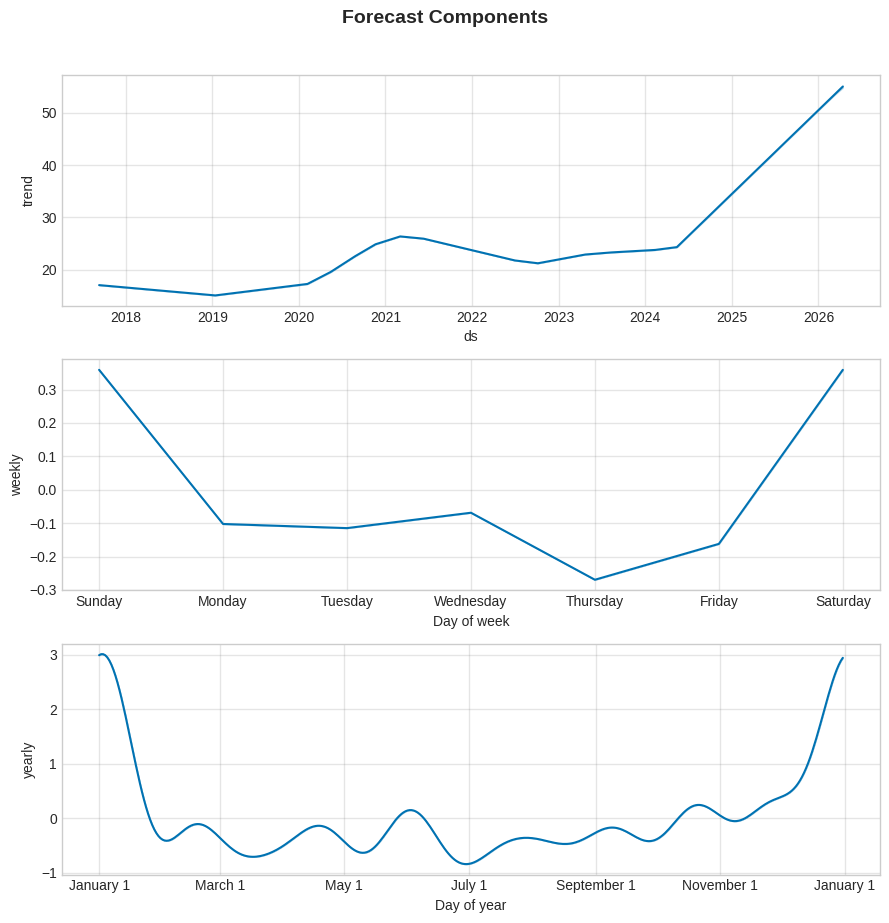

In [ ]:
# Plot components
fig = model_full.plot_components(forecast)
plt.suptitle('Forecast Components', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Forecast Table for Q1 2026
forecast_export = forecast_q1_2026[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_export.columns = ['Date', 'Predicted_Price', 'Lower_Bound', 'Upper_Bound']
forecast_export = forecast_export.round(2)
print('Silver Price Forecast for Q1 2026 (Jan-Mar):')
print(f'Rows: {len(forecast_export)}')
forecast_export.head()

Silver Price Forecast for Q1 2026 (Jan-Mar):
Rows: 85


,Date,Predicted_Price,Lower_Bound,Upper_Bound
2090,2026-01-02,53.38,48.97,58.04
2091,2026-01-05,53.53,49.18,57.94
2092,2026-01-06,53.50,49.16,57.63
2093,2026-01-07,53.52,48.88,57.81
2094,2026-01-08,53.28,48.95,57.55


In [ ]:
# Prepare data for Random Forest
features = ['Close', 'High', 'Low', 'Open', 'MA_7', 'MA_30', 'Volatility_7d', 'Month', 'DayOfWeek', 'Price_Lag_1', 'Price_Lag_7']
df_ml = df[features + ['Price']].dropna().copy()
X = df_ml[features]
y = df_ml['Price']

print(f'ML Dataset Shape: {df_ml.shape}')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

# Predictions
rf_pred = rf_model.predict(X_test_scaled)

# Metrics
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print('Random Forest Model Evaluation:')
print(f'   RMSE: ${rf_rmse:.2f}')
print(f'   MAE:  ${rf_mae:.2f}')
print(f'   R2:   {rf_r2:.4f}')

ML Dataset Shape: (2099, 12)
Random Forest Model Evaluation:
   RMSE: $13.98
   MAE:  $8.62
   R2:   -0.5908


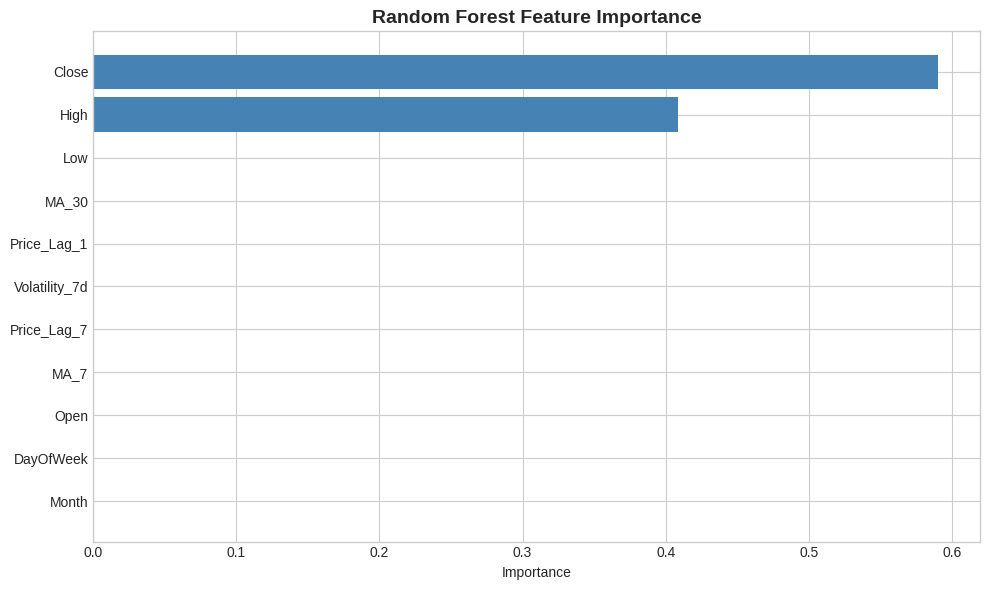

In [ ]:
# Feature Importance
importance = pd.DataFrame({'Feature': features, 'Importance': rf_model.feature_importances_})
importance = importance.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance['Feature'], importance['Importance'], color='steelblue')
ax.set_title('Random Forest Feature Importance', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()


In [ ]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Prophet'],
    'MAE': [lr_mae, rf_mae, mae],
    'RMSE': [lr_rmse, rf_rmse, rmse]
})

print(results)

               Model        MAE       RMSE
0  Linear Regression   0.619727   1.009691
1      Random Forest   8.619623  13.982474
2            Prophet  10.546016  14.817575


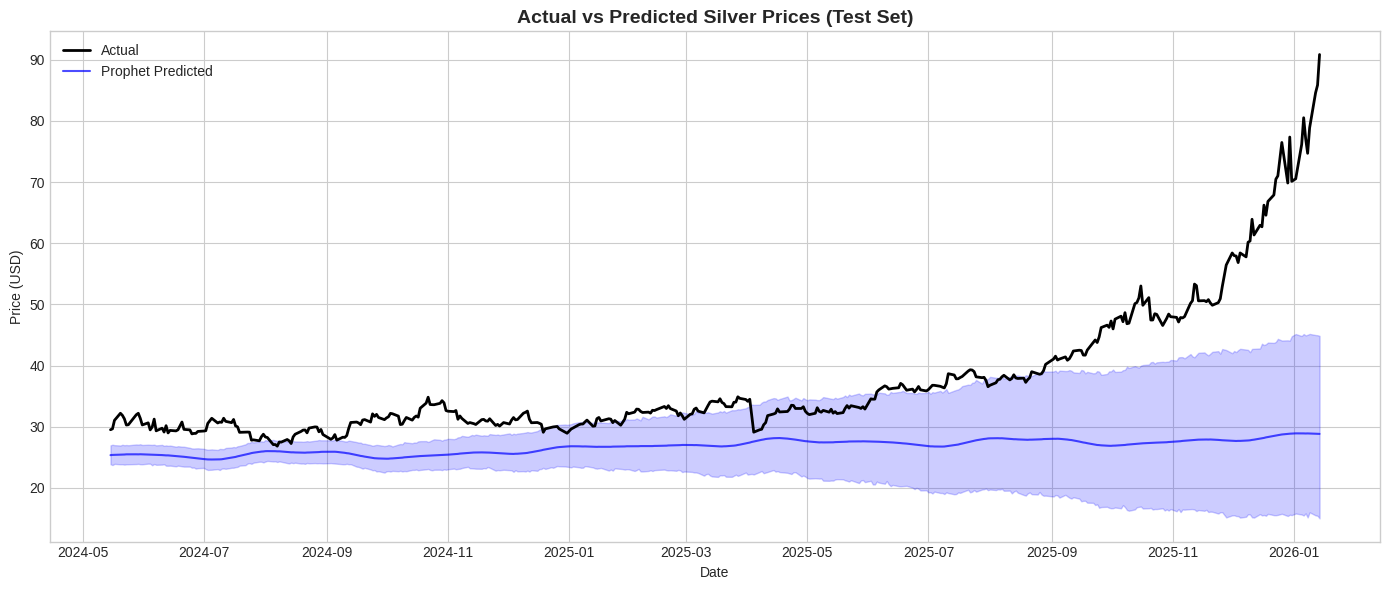

In [ ]:
# Actual vs Predicted Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(test['ds'].values, y_true, label='Actual', color='black', linewidth=2)
ax.plot(test['ds'].values, y_pred, label='Prophet Predicted', color='blue', alpha=0.7)
ax.fill_between(test['ds'].values, test_forecast['yhat_lower'].values, test_forecast['yhat_upper'].values, alpha=0.2, color='blue')
ax.set_title('Actual vs Predicted Silver Prices (Test Set)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Monthly Forecast Summary 2026
forecast_q1_2026['Month'] = forecast_q1_2026['ds'].dt.month_name()
monthly_forecast = forecast_q1_2026.groupby('Month')['yhat'].agg(['mean', 'min', 'max']).round(2)
monthly_forecast.columns = ['Avg Price', 'Min Price', 'Max Price']
monthly_forecast = monthly_forecast.reindex(['January', 'February', 'March'])
print('Monthly Price Forecast for Q1 2026:')
monthly_forecast

Monthly Price Forecast for Q1 2026:


,Avg Price,Min Price,Max Price
Month,,,
January,52.40,51.19,53.53
February,52.20,51.35,53.08
March,53.13,52.49,54.08


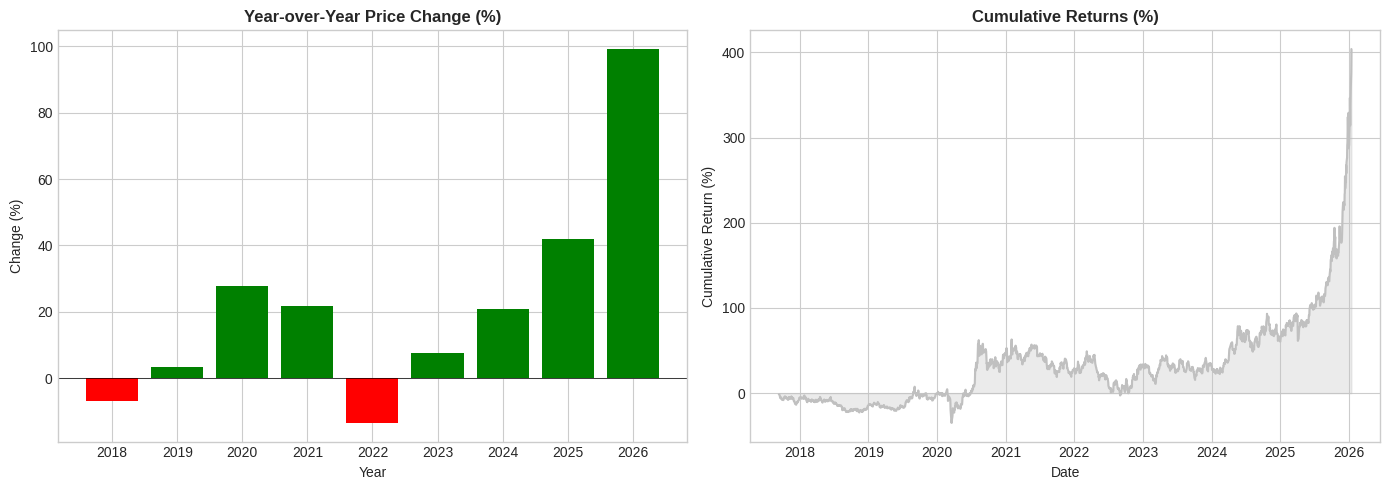

In [ ]:
# Calculate YoY growth
yearly_avg = df.groupby('Year')['Price'].mean()
yoy_growth = yearly_avg.pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# YoY Growth
colors = ['green' if x > 0 else 'red' for x in yoy_growth.dropna()]
axes[0].bar(yoy_growth.dropna().index.astype(str), yoy_growth.dropna(), color=colors)
axes[0].set_title('Year-over-Year Price Change (%)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Change (%)')
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Cumulative Returns
cumulative_returns = (1 + df['Daily_Return']/100).cumprod() - 1
axes[1].plot(df.index, cumulative_returns * 100, color='silver', linewidth=1.5)
axes[1].fill_between(df.index, cumulative_returns * 100, alpha=0.3, color='silver')
axes[1].set_title('Cumulative Returns (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Cumulative Return (%)')

plt.tight_layout()
plt.show()

In [ ]:
!pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=bbb64c003e7ff3b867c044095a531026b632e2a822b7b2ed8a805a11cfaa4409
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [ ]:
import ta
df['RSI'] = ta.momentum.RSIIndicator(df['Close']).rsi()

In [ ]:
# Moving averages
df['MA10'] = df['Close'].rolling(window=10).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()

# RSI
import ta
df['RSI'] = ta.momentum.RSIIndicator(df['Close']).rsi()

df.dropna(inplace=True)

In [ ]:
df['Target'] = df['Close'].shift(-1)
df.dropna(inplace=True)

X = df[['Close', 'MA10', 'MA50', 'RSI']]
y = df['Target']

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100)
model.fit(X, y)

df['Predicted'] = model.predict(X)

In [ ]:
def investment_signal(row):
    if row['Predicted'] > row['Close']:
        return "BUY"
    else:
        return "SELL"

df['Investment_Signal'] = df.apply(investment_signal, axis=1)

# Show latest signals
df[['Close', 'Predicted', 'Investment_Signal']].tail(10)

,Close,Predicted,Investment_Signal
Date,,,
2025-12-30,77.410004,75.973050,SELL
2025-12-31,74.625000,75.277848,BUY
2026-01-02,73.589996,76.548549,BUY
2026-01-05,76.820000,79.645002,BUY
2026-01-06,80.855003,80.272501,SELL
2026-01-07,80.900002,78.456100,SELL
2026-01-08,76.570000,79.595499,BUY
2026-01-09,79.974998,84.481598,BUY
2026-01-12,85.824997,88.189900,BUY


In [ ]:
def trading_signal(row):
    if row['RSI'] < 30 and row['Predicted'] > row['Close']:
        return "STRONG BUY"
    elif row['RSI'] > 70 and row['Predicted'] < row['Close']:
        return "STRONG SELL"
    else:
        return "HOLD"

df['Trading_Signal'] = df.apply(trading_signal, axis=1)

df[['Close', 'RSI', 'Predicted', 'Trading_Signal']].tail(10)

,Close,RSI,Predicted,Trading_Signal
Date,,,,
2025-12-30,77.410004,80.602368,75.973050,STRONG SELL
2025-12-31,74.625000,71.194921,75.277848,HOLD
2026-01-02,73.589996,68.017705,76.548549,HOLD
2026-01-05,76.820000,72.188909,79.645002,HOLD
2026-01-06,80.855003,76.340245,80.272501,STRONG SELL
2026-01-07,80.900002,76.382583,78.456100,STRONG SELL
2026-01-08,76.570000,64.433905,79.595499,HOLD
2026-01-09,79.974998,68.594410,84.481598,HOLD
2026-01-12,85.824997,74.182332,88.189900,HOLD


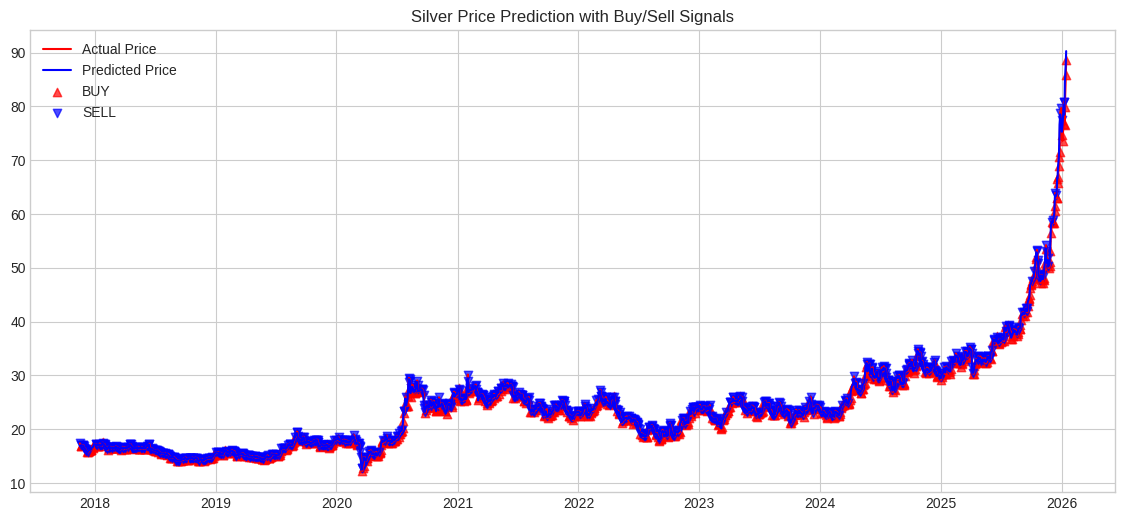

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(df['Close'], label='Actual Price', color='red')
plt.plot(df['Predicted'], label='Predicted Price',color='blue')

# Mark BUY signals
buy = df[df['Investment_Signal'] == 'BUY']
sell = df[df['Investment_Signal'] == 'SELL']

plt.scatter(buy.index, buy['Close'], marker='^', label='BUY', alpha=0.7, color='red')
plt.scatter(sell.index, sell['Close'], marker='v', label='SELL', alpha=0.7, color='blue')

plt.legend()
plt.title("Silver Price Prediction with Buy/Sell Signals")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
# Mark BUY signals
buy = df[df['Investment_Signal'] == 'BUY']
sell = df[df['Investment_Signal'] == 'SELL']

plt.scatter(buy.index, buy['Close'], marker='^', label='BUY', alpha=0.7, color='red')
plt.scatter(sell.index, sell['Close'], marker='v', label='SELL', alpha=0.7, color='blue')

plt.legend()
plt.title("Silver Price Prediction with Buy/Sell Signals")
plt.show()

NameError: name 'df' is not defined